In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Coding\Python\Telco-Customer-Churn-Analysis\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### ⬆️Here i noticed that the data type of Total Charges was "Object" which should have been "Float", i identified that there were blank spaces in the data set due to which the data type was being shown as "Object". I replaces the blank spaces with 0 and than also changed the data type to "Float".

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum().sum()

np.int64(0)

### There is no null value in the data set.

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df.duplicated().sum()

np.int64(0)

### No duplicate values found in the data set.

In [12]:
df["customerID"].duplicated().sum()

np.int64(0)

### Since customerID is primary key of the data set so just verified that there are no duplicate values in this column.

In [14]:
def convert(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
    
df["SeniorCitizen"] = df["SeniorCitizen"].apply(convert)

### Replacing the 1's and 0's value in the SeniorCitizen column with Yes and No respectively.

In [27]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


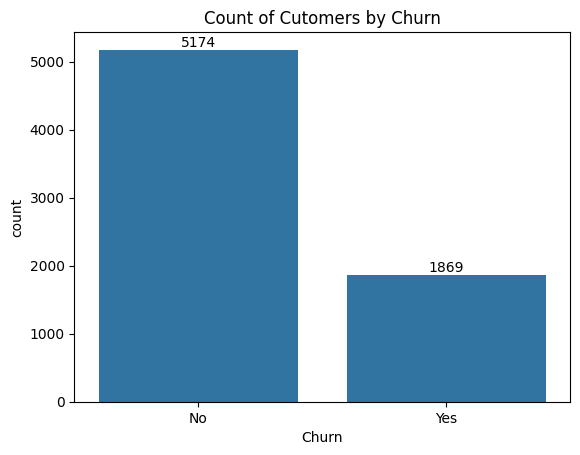

In [40]:
ax = sns.countplot(x = df["Churn"], data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Cutomers by Churn")
plt.show()

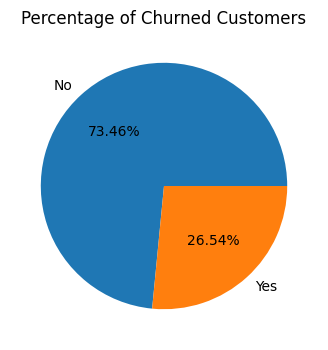

In [42]:
plt.figure(figsize = (4,4))
gb = df["Churn"].value_counts()

plt.pie(gb, labels=gb.index, autopct='%1.2f%%')
plt.title("Percentage of Churned Customers")
plt.show()

### ⬆️From the given pie chart we can conclude that 26.54% of our customers have churned out.

In [60]:
"""sns.countplot(x="gender", data=df, hue="Churn")
    plt.show()"""

'sns.countplot(x="gender", data=df, hue="Churn")\n    plt.show()'

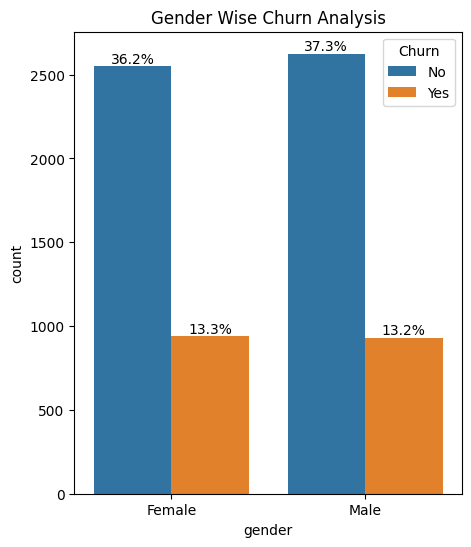

In [65]:
plt.figure(figsize=(5,6))

ax = sns.countplot(x="gender", data=df, hue="Churn")

# Add percentage labels
total = len(df)

for p in ax.patches:
    if p.get_height() > 0:  # Skip zero-height bars
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom')

plt.title("Gender Wise Churn Analysis")
plt.show()

### ⬆️We can counclude that there is very minor difference when we analyse the churn on the basis of Gender.

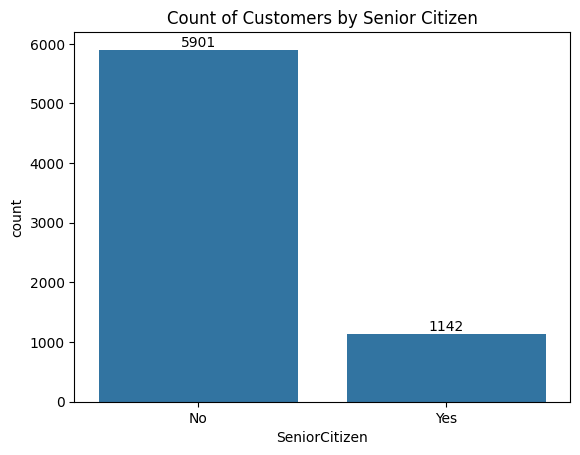

In [70]:
ax = sns.countplot(x="SeniorCitizen", data = df)
plt.title("Count of Customers by Senior Citizen")
ax.bar_label(ax.containers[0])
plt.show()

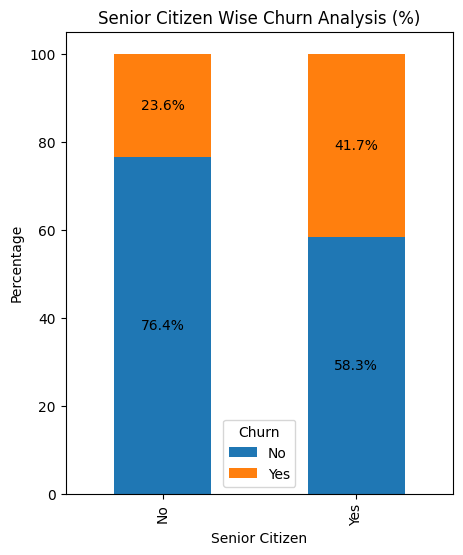

In [73]:
ct_pct = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

ax = ct_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(5,6)
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center')

plt.title("Senior Citizen Wise Churn Analysis (%)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

### Comparatively a greater percentage of people in senior citizen category have churned out.

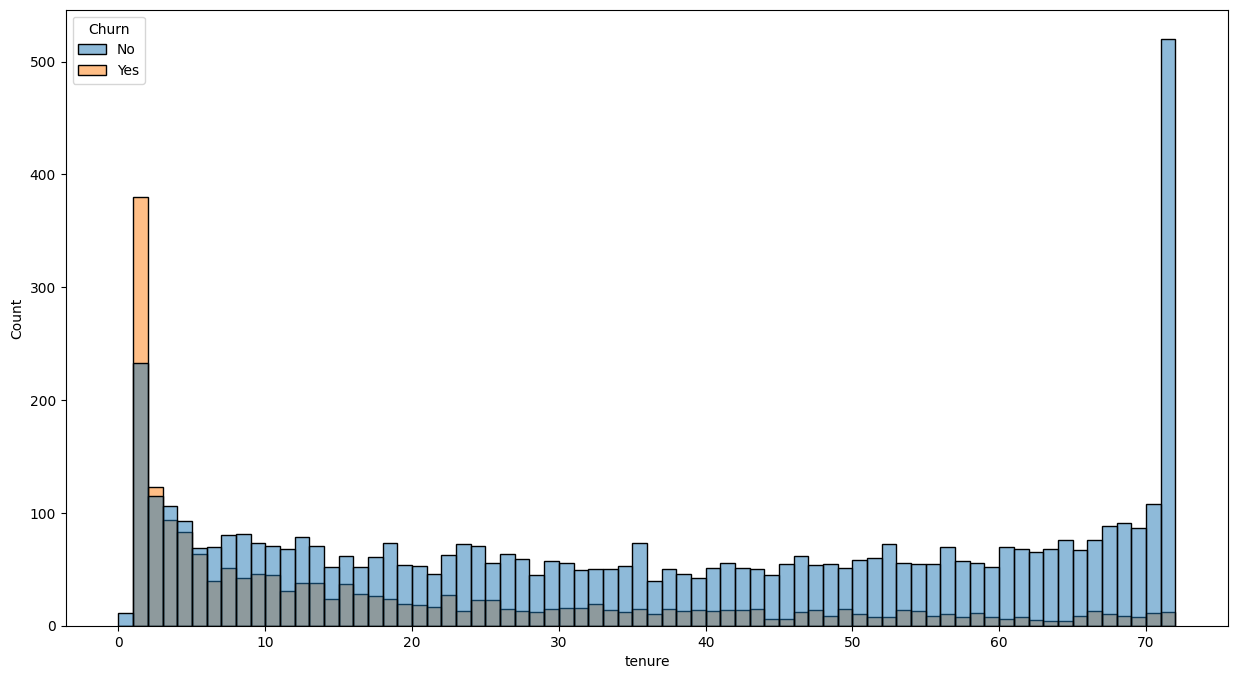

In [86]:
plt.figure(figsize = (15,8))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

### People who have used our services for a long period of time have stayed and people who have used for 1 or 2 months have churned.

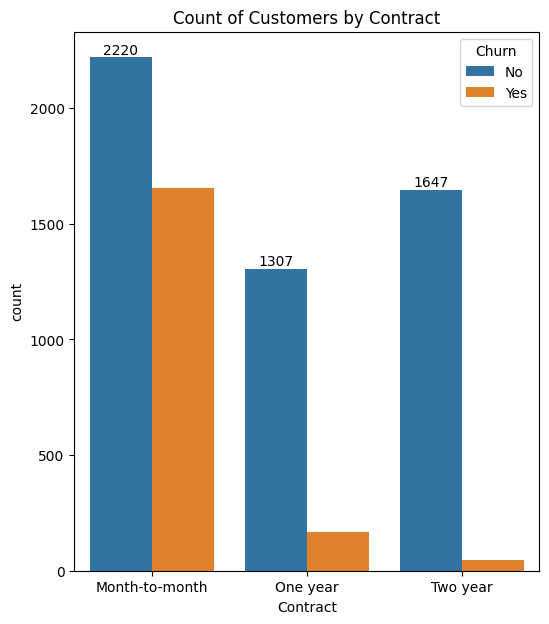

In [94]:
plt.figure(figsize =(6,7))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

### From the above chart we can conclude that the customers who bought only monthly packs they churned out more in comparison to those customers who bought One year Contract or Two years Contract.

In [99]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

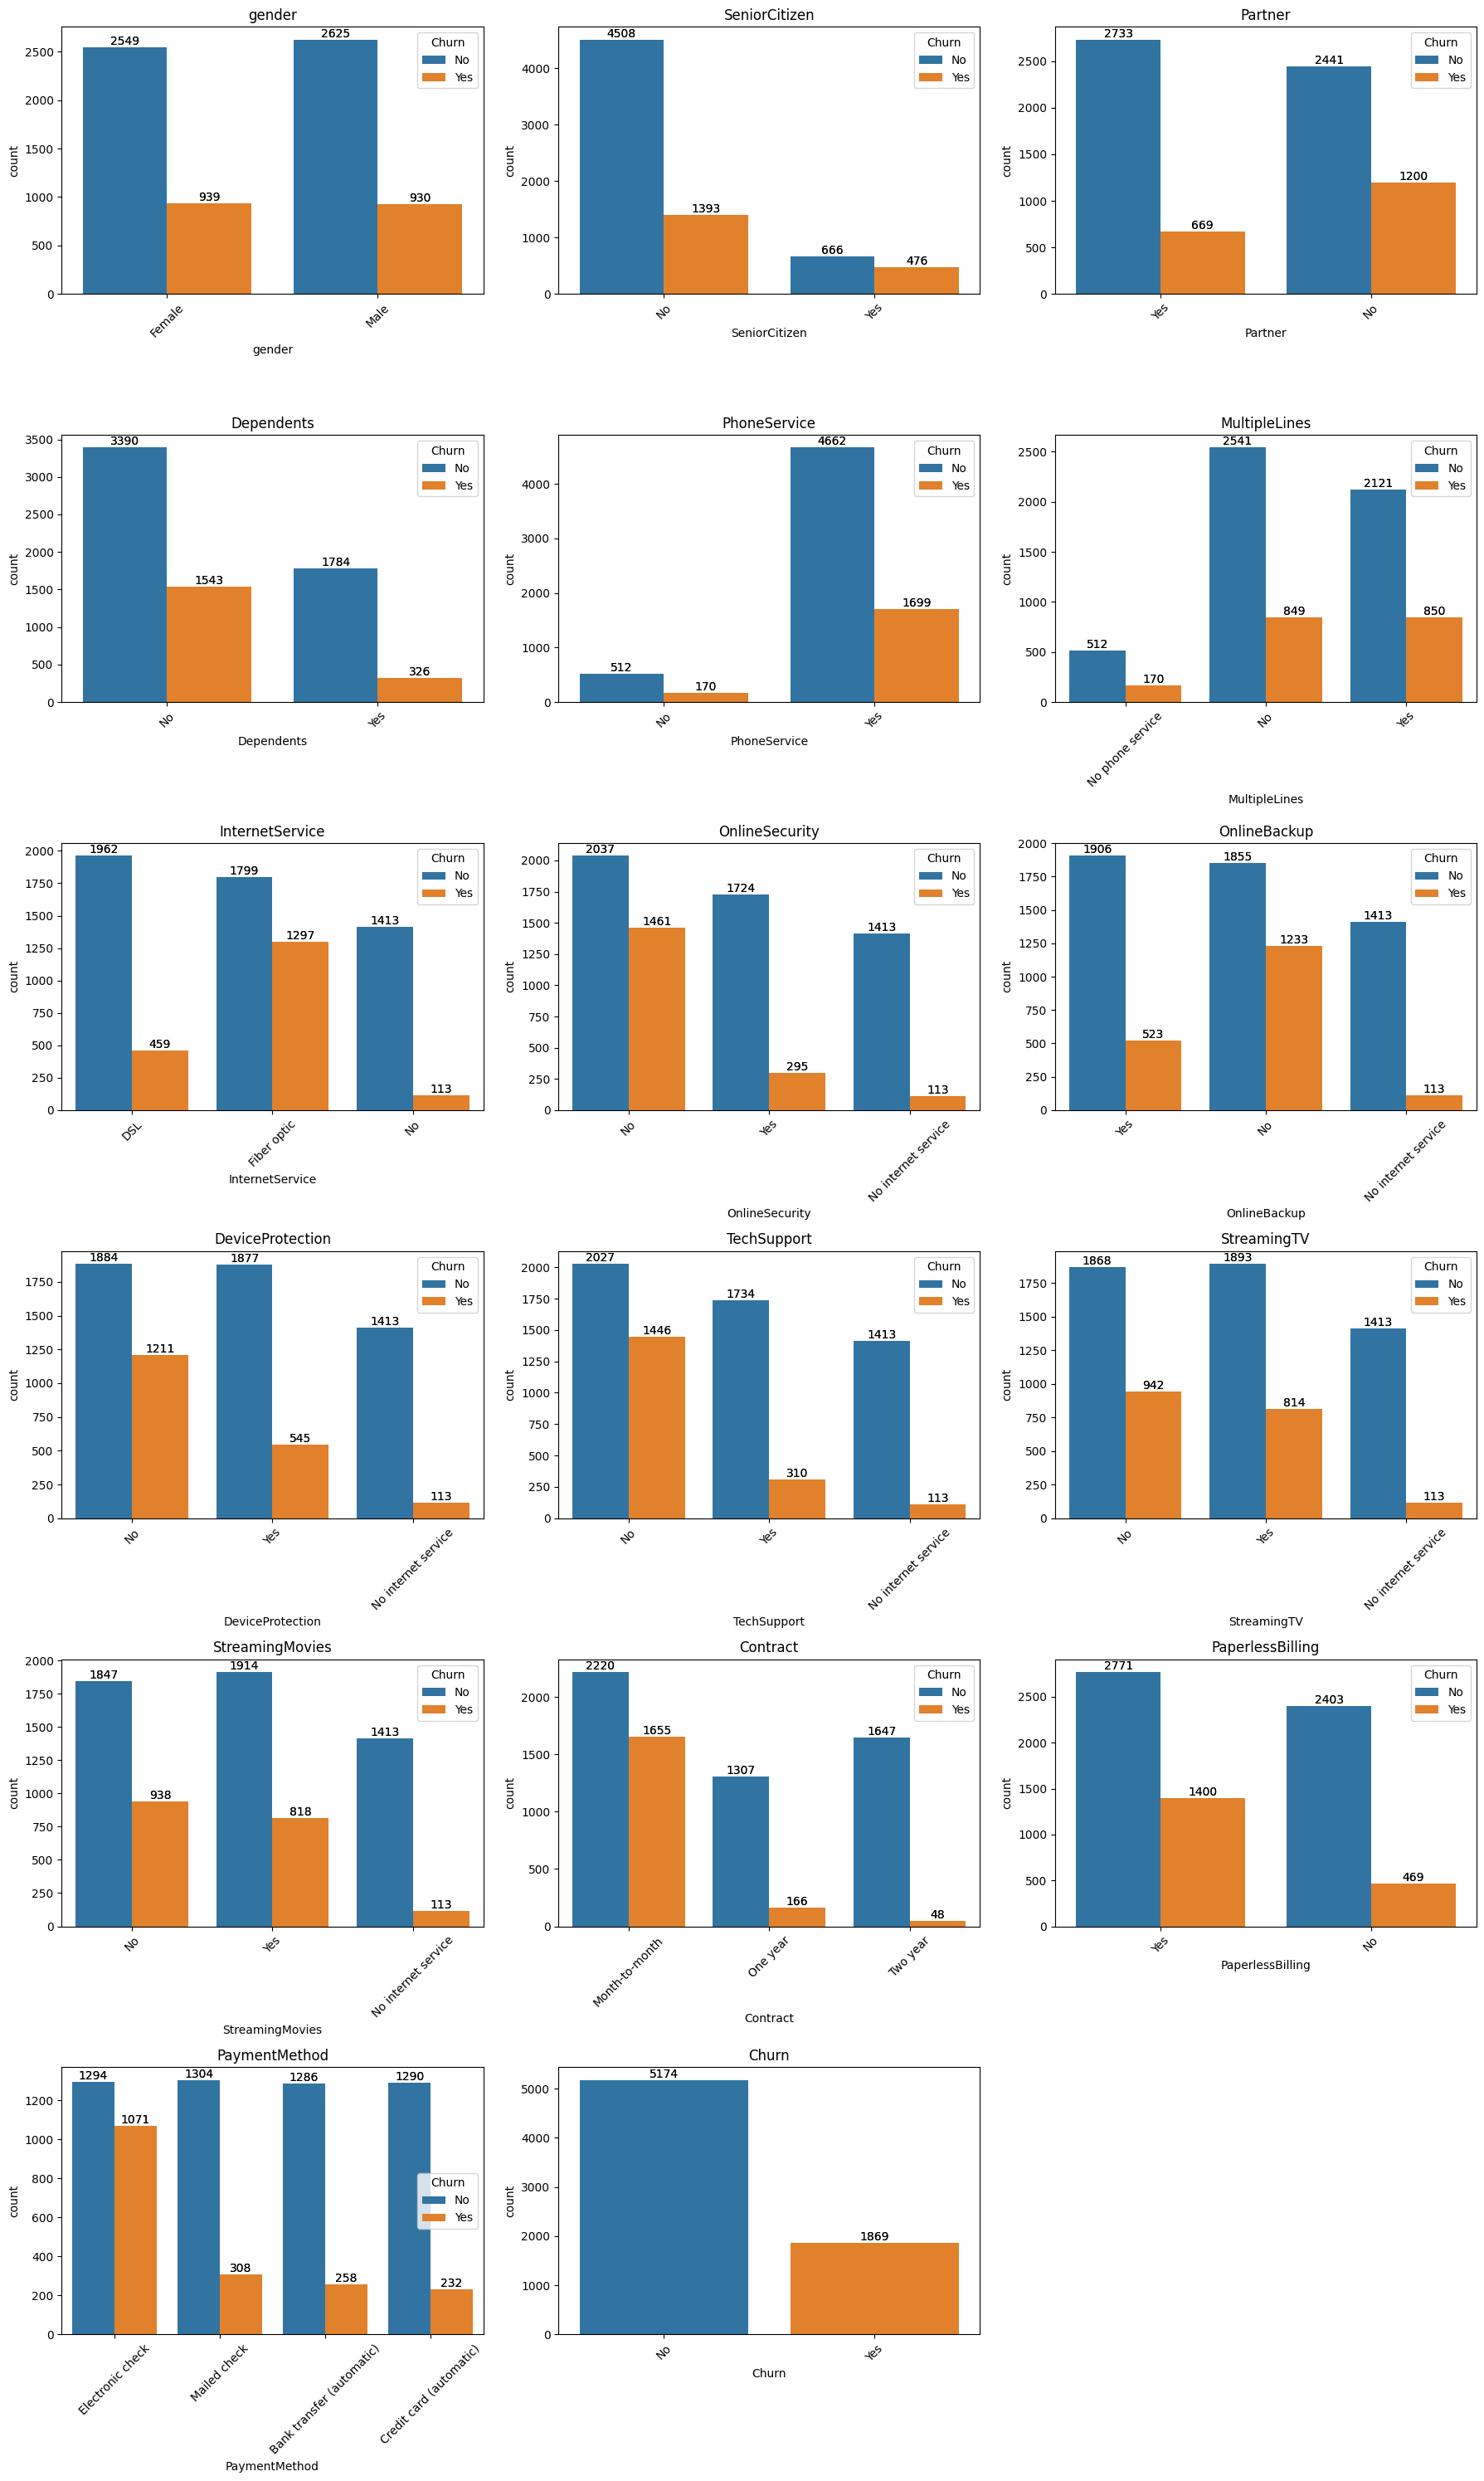

In [103]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = sns.countplot(data=df, x=col, ax=axes[i], hue = "Churn")
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Summary of Customer Churn Analysis
*Contract type is the strongest churn indicator: customers on month-to-month contracts show significantly higher churn, while one-year and two-year contracts have very low churn rates.

*Customers with fiber optic internet, no online security, no tech support, no online backup, and no device protection are much more likely to churn.

*Customers who do not have partners or dependents tend to churn more frequently than those who do.

*Gender has almost no impact on churn, while senior citizens and customers using electronic check payments exhibit relatively higher churn levels compared to other groups.

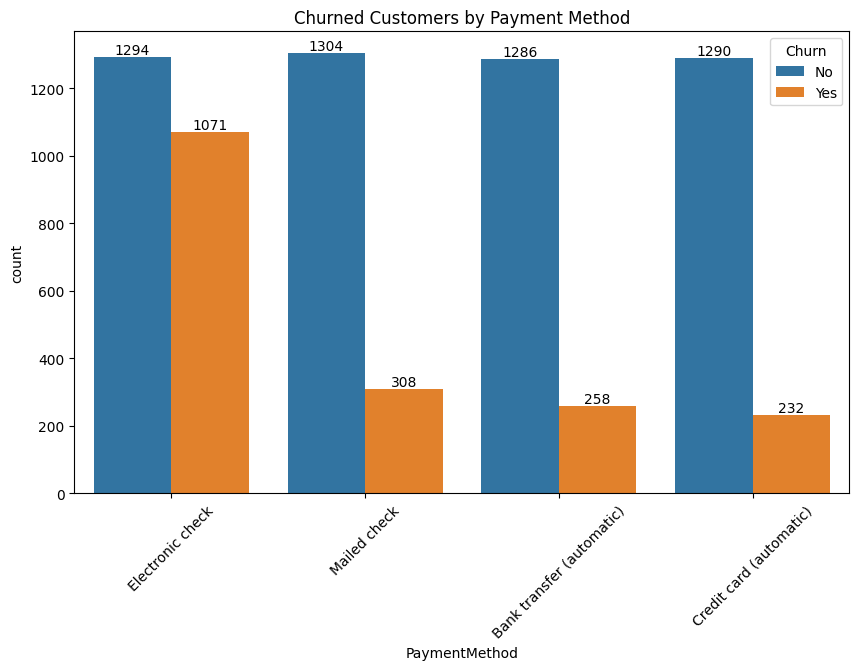

In [115]:
plt.figure(figsize =(10,6))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

### Customer is likely to churn more when the customer is paying through electronic check.